# M2A6 - Visualização de Resultados

> **Resumo:** Números sozinhos não contam toda a história. Aqui aprendemos a VISUALIZAR os resultados do modelo: matriz de confusão, curvas de aprendizado, e análise de overfitting.

**Estrutura do notebook:**

- Matriz de confusão (revisão visual)
- Curvas de aprendizado
- Detectando overfitting
- ✅ Atividades Complementares

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [2]:
digits = datasets.load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

## Matriz de Confusão — Análise Visual

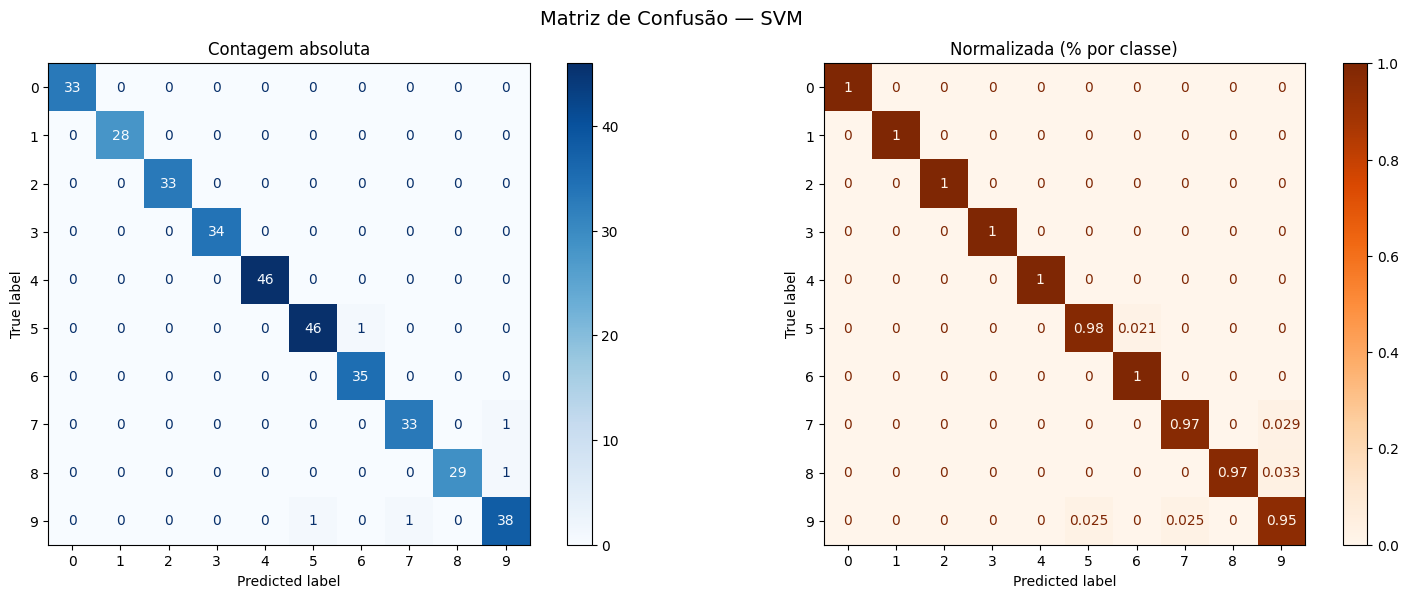

Matriz de Confusão Normalizada - Diagonal (taxa de acerto por classe):
  - Classe 0: 100.00%
  - Classe 1: 100.00%
  - Classe 2: 100.00%
  - Classe 3: 100.00%
  - Classe 4: 100.00%
  - Classe 5: 97.87%
  - Classe 6: 100.00%
  - Classe 7: 97.06%
  - Classe 8: 96.67%
  - Classe 9: 95.00%


In [3]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred = svm.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

# Visualização normalizada (percentual por classe real)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(cmap='Blues', ax=axes[0])
axes[0].set_title("Contagem absoluta")

ConfusionMatrixDisplay(cm_norm, display_labels=range(10)).plot(cmap='Oranges', ax=axes[1])
axes[1].set_title("Normalizada (% por classe)")

plt.suptitle("Matriz de Confusão — SVM", fontsize=14)
plt.tight_layout()
plt.show()

print("Matriz de Confusão Normalizada - Diagonal (taxa de acerto por classe):")
for i, val in enumerate(np.diag(cm_norm)):
    print(f"  - Classe {i}: {val*100:.2f}%")

> 📝 A versão normalizada é melhor pra identificar classes problemáticas — se uma classe tem valor baixo na diagonal, o modelo erra muito nela.

## Curvas de Aprendizado

Mostra como a performance evolui conforme o modelo vê mais dados de treino:

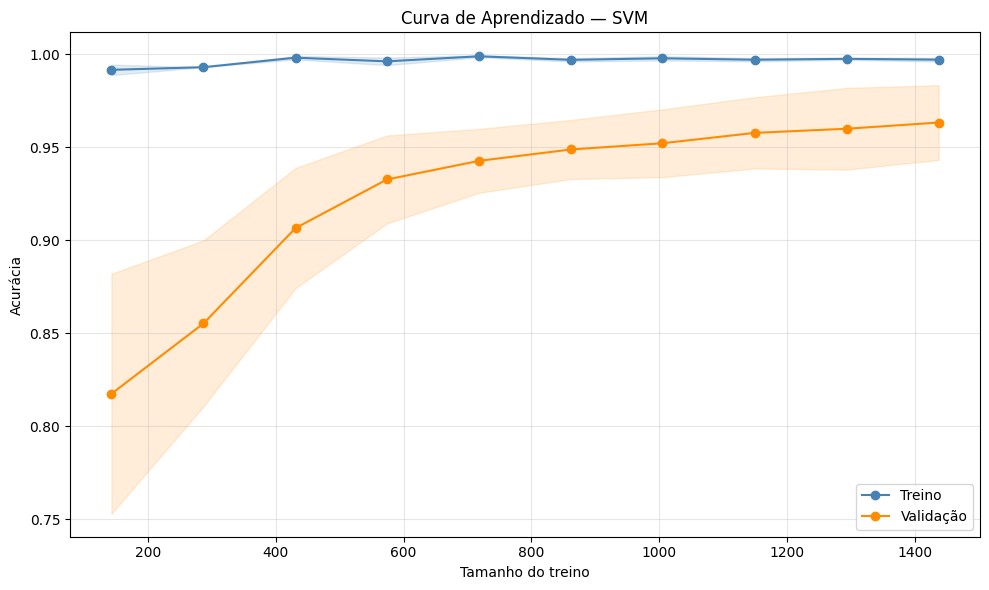

Evolução da acurácia pela curva de aprendizado (SVC):
  - Tamanho de treino:  143 | Treino: 99.16% | Validação: 81.75%
  - Tamanho de treino:  287 | Treino: 99.30% | Validação: 85.53%
  - Tamanho de treino:  431 | Treino: 99.81% | Validação: 90.65%
  - Tamanho de treino:  574 | Treino: 99.62% | Validação: 93.27%
  - Tamanho de treino:  718 | Treino: 99.89% | Validação: 94.27%
  - Tamanho de treino:  862 | Treino: 99.70% | Validação: 94.88%
  - Tamanho de treino: 1005 | Treino: 99.78% | Validação: 95.22%
  - Tamanho de treino: 1149 | Treino: 99.70% | Validação: 95.77%
  - Tamanho de treino: 1293 | Treino: 99.75% | Validação: 95.99%
  - Tamanho de treino: 1437 | Treino: 99.71% | Validação: 96.33%


In [4]:
train_sizes, train_scores, val_scores = learning_curve(
    SVC(kernel='rbf'), digits.data, digits.target,
    train_sizes=np.linspace(0.1, 1.0, 10), cv=5, scoring='accuracy'
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='darkorange')
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Treino')
plt.plot(train_sizes, val_mean, 'o-', color='darkorange', label='Validação')
plt.xlabel("Tamanho do treino")
plt.ylabel("Acurácia")
plt.title("Curva de Aprendizado — SVM")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Evolução da acurácia pela curva de aprendizado (SVC):")
for size, t_mean, v_mean in zip(train_sizes, train_mean, val_mean):
    print(f"  - Tamanho de treino: {int(size):4d} | Treino: {t_mean*100:.2f}% | Validação: {v_mean*100:.2f}%")

> 📝 **Como ler:** Se treino e validação convergem alto = bom modelo! Se treino alto mas validação baixa = overfitting.

## Detectando Overfitting

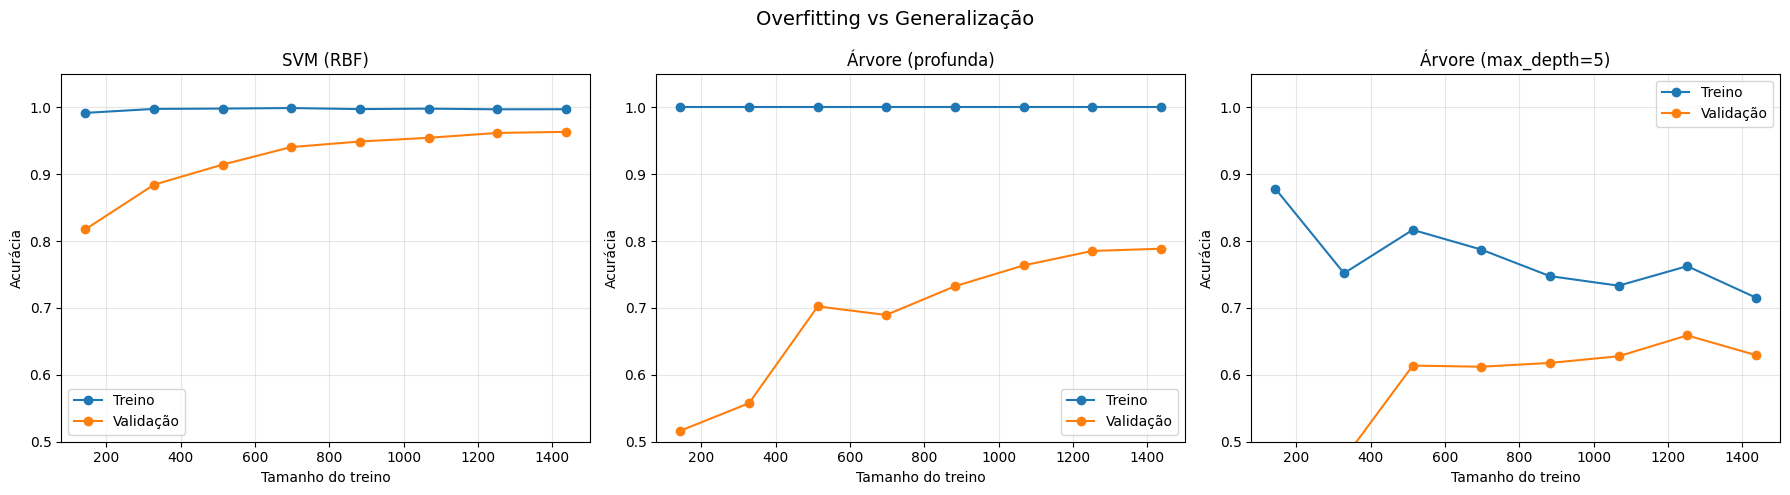

Comparação de Acurácias com 100% de Treinamento:
  - SVM (RBF)           : Treino = 99.71% | Validação = 96.33%
  - Árvore (profunda)   : Treino = 100.00% | Validação = 78.86%
  - Árvore (max_depth=5): Treino = 71.54% | Validação = 62.95%


In [5]:
# Comparar modelos: SVM (bom) vs Árvore profunda (overfitting) vs KNN
models = {
    'SVM (RBF)': SVC(kernel='rbf'),
    'Árvore (profunda)': DecisionTreeClassifier(random_state=42),
    'Árvore (max_depth=5)': DecisionTreeClassifier(max_depth=5, random_state=42),
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, model) in zip(axes, models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        model, digits.data, digits.target,
        train_sizes=np.linspace(0.1, 1.0, 8), cv=5, scoring='accuracy'
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Treino')
    ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validação')
    ax.set_title(name)
    ax.set_xlabel("Tamanho do treino")
    ax.set_ylabel("Acurácia")
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_ylim(0.5, 1.05)

plt.suptitle("Overfitting vs Generalização", fontsize=14)
plt.tight_layout()
plt.show()

print("Comparação de Acurácias com 100% de Treinamento:")
for name, model in models.items():
    _, trs, vas = learning_curve(model, digits.data, digits.target, train_sizes=[1.0], cv=5)
    print(f"  - {name:20s}: Treino = {trs.mean()*100:.2f}% | Validação = {vas.mean()*100:.2f}%")

> 📝 **Árvore profunda:** treino = 100% mas validação cai → **overfitting** (decorou o treino!)
> **Árvore limitada (depth=5):** treino e validação mais próximos → melhor generalização
> **SVM:** geralmente bom equilíbrio

## ✅ Atividades Complementares

### Curva de validação (variando hiperparâmetro)

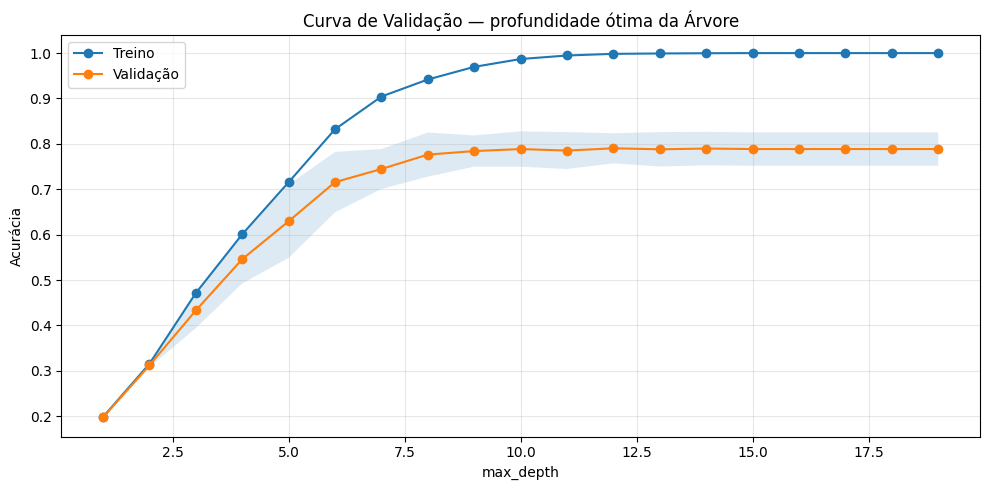

Melhor profundidade: 12
Acurácia de treino e validação por max_depth:
  - Profundidade  1: Treino = 19.82% | Validação = 19.75%
  - Profundidade  2: Treino = 31.55% | Validação = 31.22%
  - Profundidade  3: Treino = 47.13% | Validação = 43.30%
  - Profundidade  4: Treino = 60.09% | Validação = 54.60%
  - Profundidade  5: Treino = 71.55% | Validação = 62.95%
  - Profundidade  6: Treino = 83.22% | Validação = 71.57%
  - Profundidade  7: Treino = 90.43% | Validação = 74.46%
  - Profundidade  8: Treino = 94.18% | Validação = 77.63%
  - Profundidade  9: Treino = 96.97% | Validação = 78.41%
  - Profundidade 10: Treino = 98.69% | Validação = 78.86%
  - Profundidade 11: Treino = 99.47% | Validação = 78.52%
  - Profundidade 12: Treino = 99.83% | Validação = 79.02%
  - Profundidade 13: Treino = 99.92% | Validação = 78.80%
  - Profundidade 14: Treino = 99.97% | Validação = 78.97%
  - Profundidade 15: Treino = 100.00% | Validação = 78.86%
  - Profundidade 16: Treino = 100.00% | Validação = 78.86%


In [6]:
from sklearn.model_selection import validation_curve

# Variar profundidade da árvore
depths = range(1, 20)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42), digits.data, digits.target,
    param_name='max_depth', param_range=depths, cv=5, scoring='accuracy'
)

plt.figure(figsize=(10, 5))
plt.plot(depths, train_scores.mean(axis=1), 'o-', label='Treino')
plt.plot(depths, val_scores.mean(axis=1), 'o-', label='Validação')
plt.fill_between(depths, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15)
plt.xlabel("max_depth")
plt.ylabel("Acurácia")
plt.title("Curva de Validação — profundidade ótima da Árvore")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

best_depth = list(depths)[np.argmax(val_scores.mean(axis=1))]
print(f"Melhor profundidade: {best_depth}")

print("Acurácia de treino e validação por max_depth:")
for d, t_s, v_s in zip(depths, train_scores.mean(axis=1), val_scores.mean(axis=1)):
    print(f"  - Profundidade {d:2d}: Treino = {t_s*100:.2f}% | Validação = {v_s*100:.2f}%")

> 📝 **Análise da profundidade ótima:**
> - Em profundidade baixa (`max_depth=1` ou `2`), a acurácia de treino e validação são muito baixas (~19.8% e ~31.5%) -> **Subajuste (Underfitting)**.
> - A acurácia de validação atinge o pico em **max_depth=12 (79.02%)**.
> - Acima de depth 12, a acurácia de treino atinge 100.00% (a árvore decora o treino), mas a validação cai/estabiliza em 78.86%. Isso ilustra perfeitamente o **Sobreajuste (Overfitting)**, onde a complexidade extra não gera generalização.